# 21. Reconocimiento de Entidades Nombradas (NER) de tecnicismos de fútbol con BERT (BETO)

En este notebook entrenamos un modelo de **Reconocimiento de Entidades Nombradas** (*Named Entity Recognition*, NER): en vez de clasificar un documento completo (notebooks 15-20), aquí clasificamos **cada palabra** de una frase, para detectar tecnicismos futbolísticos (jugadas, remates, tipos de pase, etc.) etiquetados con la marca `FTB`.

Usamos el corpus `corpus/NER_dataset_futbol_FTB.conll.txt`, en formato **CoNLL**: una palabra por línea, con su etiqueta separada por tabulador, y una línea en blanco entre frases. Las etiquetas siguen el esquema **BIO** (*Begin-Inside-Outside*): `B-FTB` marca el inicio de un tecnicismo, `I-FTB` marca las palabras siguientes de un tecnicismo de más de una palabra (por ejemplo, "saque de puerta"), y `O` marca cualquier palabra que no forma parte de un tecnicismo.

Reutilizamos de los notebooks 15-20 el uso de BETO (`dccuchile/bert-base-spanish-wwm-cased`) como modelo preentrenado y el patrón general de trabajo (carga, partición, entrenamiento con `class_weight`, *callback* de F1 con guardado del mejor modelo). Lo nuevo aquí es la propia tarea: clasificar **cada token de la secuencia**, no un único vector por documento, lo que exige alinear las etiquetas (por palabra) con las subpalabras que genera el tokenizador de BETO.

Al final (sección 10) probamos el modelo con 10 frases nuevas: 5 con tecnicismos que sí aparecen en el corpus de entrenamiento, y 5 con tecnicismos que **no** aparecen (`penal`, `pena máxima`, `tijereta`, `offside`, `gambeta`), para comprobar si el modelo es capaz de generalizar a términos no vistos durante el entrenamiento.

Los pasos que vamos a dar son los siguientes:

1. Carga de datos
2. Particionado de datos (Train y Test)
3. Codificación de las etiquetas
4. Tokenización con el tokenizador de BETO y alineación de las etiquetas a subpalabras
5. Carga del cuerpo preentrenado de BETO
6. Congelar el cuerpo de BETO
7. Definición de la Red Neuronal completa
8. Entrenamiento del modelo
9. Evaluación del modelo
10. Prueba con frases nuevas: tecnicismos aprendidos y no aprendidos


En la siguiente imagen mostramos de forma esquemática el proceso que seguiremos:

<img src="imgs/021_NER_BETO.png" style="width: 1000px;"/>

---

## 1. Carga de datos

El fichero `corpus/NER_dataset_futbol_FTB.conll.txt` sigue el formato CoNLL: cada línea tiene una palabra y su etiqueta separadas por tabulador, y una línea en blanco separa una frase de la siguiente. Lo parseamos a una lista de frases, cada una una lista de tuplas `(palabra, etiqueta)`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)   # hay que hacerlo ANTES de importar tensorflow: el WARNING de tf.losses.sparse_softmax_cross_entropy se dispara durante el propio import

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'       # silencia mensajes informativos de TensorFlow
os.environ['TF_USE_LEGACY_KERAS'] = '1'        # necesario para que transformers use tf_keras (Keras 2) en vez de Keras 3

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import io
from collections import Counter

CORPUS_PATH = 'corpus/NER_dataset_futbol_FTB.conll.txt'

def cargar_conll(path):
    frases = []
    actual = []
    with io.open(path, encoding='utf-8') as f:
        for linea in f:
            linea = linea.rstrip('\n')
            if not linea.strip():
                if actual:
                    frases.append(actual)
                    actual = []
            else:
                palabra, etiqueta = linea.split('\t')
                actual.append((palabra, etiqueta))
        if actual:
            frases.append(actual)
    return frases

frases = cargar_conll(CORPUS_PATH)

conteo_etiquetas = Counter(etiqueta for frase in frases for _, etiqueta in frase)
longitudes = [len(frase) for frase in frases]

print(f'Total de frases: {len(frases)}')
print(f'Longitud de frase (palabras): min {min(longitudes)}, max {max(longitudes)}, media {sum(longitudes) / len(longitudes):.1f}')
print(f'Conteo de etiquetas: {dict(conteo_etiquetas)}')
print()
print('Primera frase:')
for palabra, etiqueta in frases[0]:
    print(f'  {palabra:15s} {etiqueta}')


Total de frases: 1500
Longitud de frase (palabras): min 8, max 15, media 10.0
Conteo de etiquetas: {'O': 12243, 'B-FTB': 1967, 'I-FTB': 832}

Primera frase:
  El              O
  lateral         O
  centró          O
  tras            O
  un              O
  cabezazo        B-FTB
  por             O
  la              O
  banda           O
  .               O


---

## 2. Particionado de datos (Train y Test)

Partimos a nivel de **frase** (no de palabra): cada frase completa va entera a train o a test, para no filtrar información entre ambos conjuntos. Aquí no estratificamos por etiqueta como en los notebooks 15-20 -cada frase tiene varias palabras con etiquetas distintas, no una única clase-, así que usamos una partición aleatoria simple.

In [2]:
from sklearn.model_selection import train_test_split

frases_train, frases_test = train_test_split(frases, test_size=0.2, random_state=42)

print(f'Frases de entrenamiento: {len(frases_train)}')
print(f'Frases de test:          {len(frases_test)}')


Frases de entrenamiento: 1200
Frases de test:          300


---

## 3. Codificación de las etiquetas

Solo hay tres etiquetas posibles (`O`, `B-FTB`, `I-FTB`), así que las codificamos a mano con un diccionario, en vez de con `LabelEncoder`: necesitamos el mapeo en las dos direcciones (etiqueta -> id para entrenar, id -> etiqueta para decodificar las predicciones en las secciones 8 y 10).

In [3]:
ETIQUETAS = ['O', 'B-FTB', 'I-FTB']
etiqueta_a_id = {etiqueta: i for i, etiqueta in enumerate(ETIQUETAS)}
id_a_etiqueta = {i: etiqueta for i, etiqueta in enumerate(ETIQUETAS)}

print('Etiqueta -> id:', etiqueta_a_id)


Etiqueta -> id: {'O': 0, 'B-FTB': 1, 'I-FTB': 2}


---

## 4. Tokenización con el tokenizador de BETO y alineación de las etiquetas a subpalabras

El corpus tiene una etiqueta **por palabra**, pero el tokenizador WordPiece de BETO puede partir una palabra en varias subpalabras (por ejemplo, "cabezazo" -> `cabeza` + `##zo`). Antes de poder entrenar necesitamos decidir qué etiqueta le corresponde a cada subpalabra.

Usamos el tokenizador con `is_split_into_words=True` (le pasamos la lista de palabras ya partida, en vez de el texto crudo) y su método `word_ids()`, que para cada subpalabra generada devuelve a qué palabra original pertenece (o `None` para los tokens especiales `[CLS]`/`[SEP]` y para el *padding*). Con eso podemos alinear:

- A la **primera subpalabra de cada palabra** le asignamos la etiqueta real de esa palabra.
- Al resto de subpalabras de la misma palabra, y a `[CLS]`/`[SEP]`/*padding*, los marcamos para **ignorarlos en la pérdida** durante el entrenamiento (sección 8): les asignamos una máscara a 0 en vez de a 1. Así el modelo no se penaliza por no repetir la etiqueta en cada fragmento de una misma palabra.

Como todas las frases tienen entre 8 y 15 palabras, y el WordPiece de BETO las divide como mucho en 19 subpalabras (incluyendo `[CLS]`/`[SEP]`), fijamos `MAX_LEN=32` para tener margen sin truncar ninguna frase.

In [4]:
import numpy as np
from transformers import AutoTokenizer

MODELO = 'dccuchile/bert-base-spanish-wwm-cased'   # BETO: BERT en espanol

tokenizer = AutoTokenizer.from_pretrained(MODELO)

MAX_LEN = 32

def preparar_dataset(frases):
    '''Tokeniza las frases y alinea las etiquetas por palabra a nivel de subpalabra.'''
    palabras_por_frase = [[palabra for palabra, _ in frase] for frase in frases]
    etiquetas_por_frase = [[etiqueta for _, etiqueta in frase] for frase in frases]

    codificado = tokenizer(palabras_por_frase, is_split_into_words=True, padding='max_length',
                            truncation=True, max_length=MAX_LEN, return_tensors='np')

    n = len(frases)
    y = np.zeros((n, MAX_LEN), dtype=np.int32)
    mascara_perdida = np.zeros((n, MAX_LEN), dtype=np.float32)
    ids_de_palabra = []   # uno por frase, para decodificar las predicciones en las secciones 8/9/10

    for i in range(n):
        word_ids = codificado.word_ids(i)
        ids_de_palabra.append(word_ids)
        palabra_anterior = None
        for j, id_palabra in enumerate(word_ids):
            if id_palabra is None or id_palabra == palabra_anterior:
                continue   # token especial, padding, o subpalabra que no es la primera de su palabra
            y[i, j] = etiqueta_a_id[etiquetas_por_frase[i][id_palabra]]
            mascara_perdida[i, j] = 1.0
            palabra_anterior = id_palabra

    return codificado, y, mascara_perdida, ids_de_palabra, etiquetas_por_frase


cod_train, y_train, mascara_train, ids_palabra_train, etiquetas_train = preparar_dataset(frases_train)
cod_test,  y_test,  mascara_test,  ids_palabra_test,  etiquetas_test  = preparar_dataset(frases_test)

print(f'Forma de input_ids (train): {cod_train["input_ids"].shape}')
print()
palabras_ejemplo = [p for p, _ in frases_train[0]]
tokens_ejemplo = tokenizer.convert_ids_to_tokens(cod_train['input_ids'][0])
print(f'Palabras:    {palabras_ejemplo}')
print(f'Subpalabras: {tokens_ejemplo[:len(palabras_ejemplo) + 3]} ...')
print(f'word_ids:    {ids_palabra_train[0][:len(palabras_ejemplo) + 3]} ...')
print(f'Posiciones que cuentan en la perdida: {int(mascara_train[0].sum())} de {len(palabras_ejemplo)} palabras')


Forma de input_ids (train): (1200, 32)

Palabras:    ['El', 'marcador', 'cambió', 'tras', 'un', 'achique', 'en', 'el', 'descuento', '.']
Subpalabras: ['[CLS]', 'El', 'marcador', 'cambió', 'tras', 'un', 'ach', '##ique', 'en', 'el', 'descuento', '.', '[SEP]'] ...
word_ids:    [None, 0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9, None] ...
Posiciones que cuentan en la perdida: 10 de 10 palabras


---

## 5. Carga del cuerpo preentrenado de BETO

Igual que en el notebook 20, cargamos el cuerpo con `TFAutoModel`. La diferencia con el notebook 20 es que ahora **no** nos vamos a quedar solo con el vector `[CLS]`: necesitamos la salida completa (`last_hidden_state`), un vector de 768 posiciones **por cada subpalabra** de la secuencia, porque aquí clasificamos palabra a palabra, no la frase entera de una vez.

In [5]:
from transformers import TFAutoModel
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

bert = TFAutoModel.from_pretrained(MODELO)

print(f'Parametros del cuerpo de BETO: {bert.num_parameters():,}')
print(f'Dimension de last_hidden_state por subpalabra: {bert.config.hidden_size}')


Parametros del cuerpo de BETO: 109,850,880
Dimension de last_hidden_state por subpalabra: 768


---

## 6. Congelar el cuerpo de BETO

Igual que en el notebook 20, se puede hacer *fine-tuning* del cuerpo de BETO o dejarlo congelado y usarlo solo como extractor de características. Aquí el corpus es pequeño (1.200 frases de entrenamiento, de 8 a 15 palabras cada una), así que el coste de tener el cuerpo congelado es bajo incluso en CPU: por eso este notebook mantiene `bert.trainable = False`, para que se pueda ejecutar rápido en cualquier equipo.

La comparación con el *fine-tuning* completo del cuerpo de BETO (con GPU) se hace en la versión de este notebook para Google Colab, `21_BERT_BETO_NER_tecnicismos_futbol_colab.ipynb`.

In [6]:
bert.trainable = False

print(f'bert.trainable = {bert.trainable}')


bert.trainable = False


---

## 7. Definición de la Red Neuronal completa

A diferencia de los notebooks 15-20, donde la cabeza clasificadora recibía **un único vector** por documento, aquí la cabeza recibe la secuencia completa de vectores (`last_hidden_state`, forma `(MAX_LEN, 768)`) y produce una predicción **por cada posición** de la secuencia: `Dropout` -> `Dense` con `softmax` sobre las 3 etiquetas, aplicada de forma independiente a cada subpalabra (Keras aplica una capa `Dense` sobre la última dimensión de un tensor 3D, sin necesidad de nada especial). No añadimos una capa oculta intermedia como en los notebooks 15-20: para clasificar cada token por separado, con un vector de 768 posiciones ya contextualizado por las 12 capas de BETO, una única capa `Dense` es la cabeza estándar en las tareas de NER con BERT.

In [7]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Dropout

tf.keras.utils.set_random_seed(42)   # fija a la vez las semillas de Python, NumPy y TensorFlow
tf.config.experimental.enable_op_determinism()   # evita variaciones por el orden de operaciones en coma flotante entre ejecuciones (seguro aqui: el cuerpo esta congelado, sin gradientes dispersos)

input_ids = Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

salida_bert = bert(input_ids=input_ids, attention_mask=attention_mask)
x = Dropout(0.2)(salida_bert.last_hidden_state)
salidas = Dense(len(ETIQUETAS), activation='softmax')(x)

model = Model(inputs=[input_ids, attention_mask], outputs=salidas)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()


Model: "model"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_ids (InputLayer)      [(None, 32)]                 0         []                            


 attention_mask (InputLayer  [(None, 32)]                 0         []                            


...

 dense (Dense)               (None, 32, 3)                2307      ['dropout_37[0][0]']          


Total params: 109853187 (419.06 MB)


Trainable params: 2307 (9.01 KB)


Non-trainable params: 109850880 (419.05 MB)


__________________________________________________________________________________________________


---

## 8. Entrenamiento del modelo

Igual que en los notebooks 15-20, compensamos el desbalanceo de clases: aquí la etiqueta `O` es mucho más frecuente que `B-FTB`/`I-FTB` (ver la sección 1), así que calculamos un peso por etiqueta con `compute_class_weight` a partir de las posiciones reales (sin contar las que la sección 4 marcó para ignorar).

A diferencia de los notebooks 15-20, Keras no tiene aquí un parámetro `class_weight` directo -ese parámetro pondera por documento, no por posición de la secuencia-, así que construimos nosotros mismos una matriz `sample_weight` del mismo tamaño que `y`: combina la máscara de la sección 4 (0 en las posiciones que hay que ignorar) con el peso de la etiqueta real de cada posición.

El *callback* `F1Checkpoint` sigue el mismo patrón que en los notebooks anteriores, pero la métrica que usa para decidir el mejor modelo es distinta: en vez del F1 ponderado de `sklearn` sobre documentos completos, aquí decodificamos las predicciones subpalabra a palabra (con la misma lógica de `word_ids()` de la sección 4) y calculamos el **F1 a nivel de entidad** con la librería `seqeval`, el estándar habitual para evaluar NER -cuenta como acierto una entidad completa, no cada palabra suelta por separado-.

In [8]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import Callback
from seqeval.metrics import f1_score as f1_entidad

posiciones_validas = mascara_train == 1
pesos = compute_class_weight('balanced', classes=np.unique(y_train[posiciones_validas]), y=y_train[posiciones_validas])
peso_por_clase = {clase: peso for clase, peso in zip(np.unique(y_train[posiciones_validas]), pesos)}
print('Pesos por clase:', {id_a_etiqueta[c]: round(p, 3) for c, p in peso_por_clase.items()})

sample_weight_train = np.zeros_like(mascara_train)
for clase, peso in peso_por_clase.items():
    sample_weight_train[y_train == clase] = peso
sample_weight_train *= mascara_train   # las posiciones ignoradas (mascara=0) se quedan a peso 0


def decodificar_predicciones(logits, ids_de_palabra):
    '''Convierte las predicciones de subpalabra a palabra, quedandonos con la primera subpalabra de cada palabra.'''
    predicciones_id = np.argmax(logits, axis=-1)
    resultado = []
    for fila, word_ids in zip(predicciones_id, ids_de_palabra):
        etiquetas_frase = []
        palabra_anterior = None
        for id_etiqueta, id_palabra in zip(fila, word_ids):
            if id_palabra is None or id_palabra == palabra_anterior:
                continue
            etiquetas_frase.append(id_a_etiqueta[id_etiqueta])
            palabra_anterior = id_palabra
        resultado.append(etiquetas_frase)
    return resultado


class F1Checkpoint(Callback):
    '''Igual que en los notebooks 15-20, pero con F1 a nivel de entidad (seqeval) en vez de F1 ponderado por documento.'''

    def __init__(self, filepath, X_train, ids_palabra_train, etiquetas_train, X_val, ids_palabra_val, etiquetas_val):
        super().__init__()
        self.filepath = filepath
        self.X_train = X_train
        self.ids_palabra_train = ids_palabra_train
        self.etiquetas_train = etiquetas_train
        self.X_val = X_val
        self.ids_palabra_val = ids_palabra_val
        self.etiquetas_val = etiquetas_val
        self.best_f1 = -1.0
        self.f1_train_history = []
        self.f1_val_history = []

    def on_epoch_end(self, epoch, logs=None):
        logits_train = self.model.predict(self.X_train, verbose=0)
        logits_val = self.model.predict(self.X_val, verbose=0)

        pred_train = decodificar_predicciones(logits_train, self.ids_palabra_train)
        pred_val = decodificar_predicciones(logits_val, self.ids_palabra_val)

        f1_train = f1_entidad(self.etiquetas_train, pred_train)
        f1_val = f1_entidad(self.etiquetas_val, pred_val)

        self.f1_train_history.append(f1_train)
        self.f1_val_history.append(f1_val)

        if f1_val > self.best_f1:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> mejora, guardando modelo en {self.filepath}')
            self.best_f1 = f1_val
            self.model.save(self.filepath)
        else:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> no mejora el mejor val_f1 ({self.best_f1:.4f})')


MODEL_PATH = 'models/21_mejor_modelo_ner_futbol_beto.keras'
os.makedirs('models', exist_ok=True)

checkpoint_f1 = F1Checkpoint(
    filepath=MODEL_PATH,
    X_train=[cod_train['input_ids'], cod_train['attention_mask']], ids_palabra_train=ids_palabra_train, etiquetas_train=etiquetas_train,
    X_val=[cod_test['input_ids'], cod_test['attention_mask']], ids_palabra_val=ids_palabra_test, etiquetas_val=etiquetas_test
)


Pesos por clase: {'O': np.float64(0.41), 'B-FTB': np.float64(2.539), 'I-FTB': np.float64(5.901)}


In [9]:
history = model.fit(
    [cod_train['input_ids'], cod_train['attention_mask']], y_train,
    sample_weight=sample_weight_train,
    batch_size=16,
    epochs=20,
    verbose=1,
    callbacks=[checkpoint_f1])

history.history['f1'] = checkpoint_f1.f1_train_history
history.history['val_f1'] = checkpoint_f1.f1_val_history


Epoch 1/10


 1/75 [..............................] - ETA: 8:04 - loss: 0.3787 - accuracy: 0.1680

 2/75 [..............................] - ETA: 23s - loss: 0.4363 - accuracy: 0.1660 

 3/75 [>.............................] - ETA: 23s - loss: 0.4193 - accuracy: 0.1667

 4/75 [>.............................] - ETA: 22s - loss: 0.4045 - accuracy: 0.1689

...

73/75 [============================>.] - ETA: 0s - loss: 0.0072 - accuracy: 0.8417

74/75 [============================>.] - ETA: 0s - loss: 0.0072 - accuracy: 0.8418

75/75 [==============================] - ETA: 0s - loss: 0.0072 - accuracy: 0.8415


Epoch 10: f1: 0.9915 - val_f1: 0.9949 -> mejora, guardando modelo en models/21_mejor_modelo_ner_futbol_beto.keras


75/75 [==============================] - 61s 819ms/step - loss: 0.0072 - accuracy: 0.8415


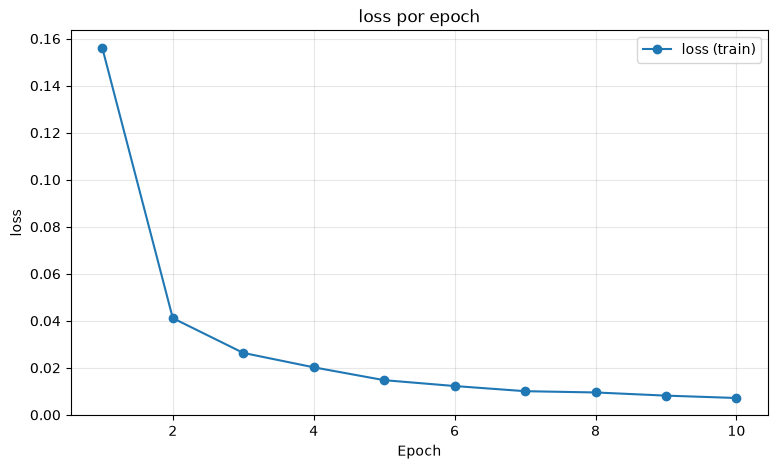

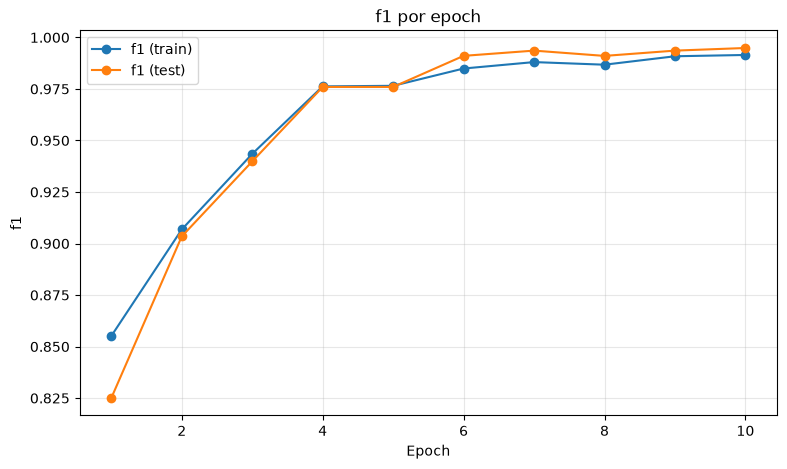

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metric(history, name):
    metric_train = history.history[name]
    epochs_range = range(1, len(metric_train) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs_range, metric_train, marker='o', label=f'{name} (train)')
    if f'val_{name}' in history.history:
        plt.plot(epochs_range, history.history[f'val_{name}'], marker='o', label=f'{name} (test)')
    plt.title(f'{name} por epoch')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(history, 'loss')
plot_metric(history, 'f1')


---

## 9. Evaluación del modelo

Cargamos el modelo del epoch con mejor F1 de entidad en test, y lo evaluamos de dos formas:

1. **A nivel de palabra**, con `classification_report` de `sklearn` sobre las tres etiquetas (`O`, `B-FTB`, `I-FTB`), igual que en los notebooks 15-20.
2. **A nivel de entidad**, con `seqeval`: la métrica que de verdad importa en NER, porque cuenta como acierto una entidad completa (todas sus palabras con la etiqueta correcta), no cada palabra por separado.

In [11]:
from tensorflow.keras.models import load_model
from transformers import TFBertModel

modelo_ner = load_model(MODEL_PATH, custom_objects={'TFBertModel': TFBertModel})
print(f'Modelo cargado desde: {MODEL_PATH}')


Modelo cargado desde: models/21_mejor_modelo_ner_futbol_beto.keras


In [12]:
from sklearn.metrics import classification_report as sk_classification_report

logits_test = modelo_ner.predict([cod_test['input_ids'], cod_test['attention_mask']], verbose=0)
predicciones_id_test = np.argmax(logits_test, axis=-1)

y_test_plano = y_test[mascara_test == 1]
y_pred_plano = predicciones_id_test[mascara_test == 1]

print('--- Evaluacion a nivel de palabra ---')
print(sk_classification_report(y_test_plano, y_pred_plano, target_names=ETIQUETAS))


--- Evaluacion a nivel de palabra ---
              precision    recall  f1-score   support

           O       1.00      1.00      1.00      2479
       B-FTB       1.00      1.00      1.00       389
       I-FTB       0.98      1.00      0.99       153

    accuracy                           1.00      3021
   macro avg       0.99      1.00      1.00      3021
weighted avg       1.00      1.00      1.00      3021



In [13]:
from seqeval.metrics import classification_report as seqeval_classification_report, f1_score as f1_entidad, precision_score as precision_entidad, recall_score as recall_entidad

pred_test = decodificar_predicciones(logits_test, ids_palabra_test)

print('--- Evaluacion a nivel de entidad (seqeval) ---')
print(f'Precision: {precision_entidad(etiquetas_test, pred_test):.4f}')
print(f'Recall:    {recall_entidad(etiquetas_test, pred_test):.4f}')
print(f'F1:        {f1_entidad(etiquetas_test, pred_test):.4f}')
print()
print(seqeval_classification_report(etiquetas_test, pred_test))


--- Evaluacion a nivel de entidad (seqeval) ---
Precision: 0.9923
Recall:    0.9974
F1:        0.9949

              precision    recall  f1-score   support

         FTB       0.99      1.00      0.99       389

   micro avg       0.99      1.00      0.99       389
   macro avg       0.99      1.00      0.99       389
weighted avg       0.99      1.00      0.99       389



---

## 10. Prueba con frases nuevas: tecnicismos aprendidos y no aprendidos

Por último, probamos el modelo con 10 frases nuevas que no están en el corpus:

- **5 frases con tecnicismos que sí aparecen** en el corpus de entrenamiento (`cabezazo`, `chilena`, `penalti`, `regate`, `fuera de juego`).
- **5 frases con tecnicismos que no aparecen** en el corpus (`penal`, `pena máxima`, `tijereta`, `offside`, `gambeta`) -son sinónimos o variantes de los cinco anteriores, para comprobar si el modelo generaliza a la palabra nueva o solo reconoce las palabras exactas que ha visto en el entrenamiento-.

Para tokenizar estas frases nuevas en palabras (antes de pasarlas al tokenizador de BETO) usamos spaCy, igual que en los notebooks 1-9, en vez de un simple `.split()`: así separamos también los signos de puntuación como palabras independientes, igual que hace el propio corpus de entrenamiento.

In [14]:
import spacy

nlp = spacy.load('es_core_news_sm')


def predecir_entidades(texto):
    '''Tokeniza una frase con spaCy, la pasa por el modelo de NER y decodifica las etiquetas predichas por palabra.'''
    palabras = [token.text for token in nlp(texto)]
    codificado = tokenizer([palabras], is_split_into_words=True, padding='max_length',
                            truncation=True, max_length=MAX_LEN, return_tensors='tf')
    logits = modelo_ner.predict([codificado['input_ids'], codificado['attention_mask']], verbose=0)
    etiquetas_pred = decodificar_predicciones(logits, [codificado.word_ids(0)])[0]
    return list(zip(palabras, etiquetas_pred))


def extraer_tecnicismos(pares_palabra_etiqueta):
    '''Reconstruye los tecnicismos (posiblemente de varias palabras) a partir de las etiquetas BIO.'''
    tecnicismos = []
    actual = []
    for palabra, etiqueta in pares_palabra_etiqueta:
        if etiqueta == 'B-FTB':
            if actual:
                tecnicismos.append(' '.join(actual))
            actual = [palabra]
        elif etiqueta == 'I-FTB' and actual:
            actual.append(palabra)
        else:
            if actual:
                tecnicismos.append(' '.join(actual))
            actual = []
    if actual:
        tecnicismos.append(' '.join(actual))
    return tecnicismos


frases_prueba = [
    # 5 frases con tecnicismos ya vistos en el corpus de entrenamiento
    'El defensa hizo un cabezazo espectacular en el área.',
    'El delantero marcó con una chilena imposible de parar.',
    'El árbitro señaló penalti tras la falta en el área.',
    'El extremo hizo un regate y dejó atrás a dos rivales.',
    'El linier levantó la bandera por fuera de juego.',
    # 5 frases con tecnicismos que NO aparecen en el corpus de entrenamiento
    'El árbitro pitó un penal claro dentro del área.',
    'El colegiado señaló pena máxima tras la mano en el área.',
    'El atacante remató con una tijereta increíble.',
    'El asistente marcó offside justo antes del gol.',
    'El volante hizo una gambeta para superar a su marcador.',
]

for frase in frases_prueba:
    pares = predecir_entidades(frase)
    tecnicismos = extraer_tecnicismos(pares)
    print(f'Frase: {frase}')
    print(f'  Tecnicismos detectados: {tecnicismos if tecnicismos else "(ninguno)"}')
    print()


Frase: El defensa hizo un cabezazo espectacular en el área.
  Tecnicismos detectados: ['cabezazo espectacular']

Frase: El delantero marcó con una chilena imposible de parar.
  Tecnicismos detectados: ['chilena']



Frase: El árbitro señaló penalti tras la falta en el área.
  Tecnicismos detectados: ['penalti', 'falta']

Frase: El extremo hizo un regate y dejó atrás a dos rivales.
  Tecnicismos detectados: ['regate']



Frase: El linier levantó la bandera por fuera de juego.
  Tecnicismos detectados: (ninguno)

Frase: El árbitro pitó un penal claro dentro del área.
  Tecnicismos detectados: ['penal claro']



Frase: El colegiado señaló pena máxima tras la mano en el área.
  Tecnicismos detectados: ['mano']

Frase: El atacante remató con una tijereta increíble.
  Tecnicismos detectados: ['tijereta']



Frase: El asistente marcó offside justo antes del gol.
  Tecnicismos detectados: ['offside']

Frase: El volante hizo una gambeta para superar a su marcador.
  Tecnicismos detectados: ['gambeta']



## Conclusiones

* El `F1Checkpoint` se quedó en el **epoch 10** (val_f1 = 0.9949), con el cuerpo de BETO congelado. En test: F1 de entidad (seqeval) de **0.9949** (precisión 0.9923, recall 0.9974) y F1 de palabra de 1.00.

* Estas cifras hay que interpretarlas con cautela: **los 42 tecnicismos del corpus aparecen tanto en train como en test** (la partición es aleatoria por frase, no por tecnicismo, y con solo 42 términos repartidos en 1.500 frases, los 42 acaban en los dos conjuntos). Esto está bien -es la partición train/test habitual-, pero significa que el test no evalúa si el modelo reconoce tecnicismos nuevos, sino si reconoce, en frases distintas, los mismos 42 términos que ya ha visto en el entrenamiento. La prueba real de generalización es la sección 10.

* En el notebook de Colab (`bert.trainable = True`, GPU), el F1 de entidad en test llega a **1.0000** desde el primer epoch. Con un corpus tan pequeño y homogéneo, el fine-tuning no aporta ninguna ventaja medible frente al cuerpo congelado.

* En las 10 frases nuevas, el fine-tuning solo cambia uno de los diez resultados (recupera "fuera de juego"); en el resto, ambas configuraciones coinciden exactamente:

    | Tecnicismo | Congelado | Fine-tuning (Colab) |
    |---|---|---|
    | cabezazo *(aprendido)* | "cabezazo espectacular" | "cabezazo espectacular" |
    | chilena *(aprendido)* | "chilena" ✅ | "chilena" ✅ |
    | penalti / falta *(aprendidos)* | "penalti", "falta" ✅ | "penalti", "falta" ✅ |
    | regate *(aprendido)* | "regate" ✅ | "regate" ✅ |
    | fuera de juego *(aprendido)* | (ninguno) ❌ | "fuera de juego" ✅ |
    | penal *(no aprendido)* | "penal claro" | "penal claro" |
    | pena máxima *(no aprendido)* | "mano" ❌ | "mano" ❌ |
    | tijereta *(no aprendido)* | "tijereta" ✅ | "tijereta" ✅ |
    | offside *(no aprendido)* | "offside" ✅ | "offside" ✅ |
    | gambeta *(no aprendido)* | "gambeta" ✅ | "gambeta" ✅ |

* El modelo generaliza a 3 de los 5 tecnicismos no vistos (`tijereta`, `offside`, `gambeta`), sinónimos de términos aprendidos, igual con el cuerpo congelado que con fine-tuning: esa capacidad viene del preentrenamiento general de BETO, no del ajuste a este corpus.

* Los dos fallos que persisten en ambas configuraciones apuntan a los límites del corpus, no del modelo: "cabezazo espectacular" y "penal claro" extienden la entidad al adjetivo siguiente (el corpus nunca etiqueta un adjetivo como `I-FTB`); "pena máxima" se confunde con "mano", probablemente por asociación con "mano a mano" (presente 44 veces en el corpus).